In [1]:
# Task 1: Load Raw Data
# Author: Kappari Vaishnavi - Gachibowli Project
import pandas as pd
import numpy as np

# Load your Integrated Dataset from GitHub (your link)
url = "https://raw.githubusercontent.com/Vaishureddy98/uber-traffic-gachibowli-vaishnavi/main/Integrated_Dataset_Gachibowli_Kappari_Vaishnavi.csv"
df = pd.read_csv(url)

# Also load original traffic data if you have it locally
# df_traffic = pd.read_csv('/content/Dataset_Uber_Traffic.csv')

print("Data Loaded Successfully!")
print(f"Shape: {df.shape}")
df.head()

Data Loaded Successfully!
Shape: (20, 16)


,DateTime,Junction,Vehicles,ID,Date,Temperature_C,Precipitation_mm,Humidity_pct,Wind_Speed_kmph,Weather_Condition,Event_Name,Event_Type,Is_Holiday,Is_Event,Created_By,Location
0,2015-11-01 00:00:00,3,114,20151101000,2015-11-01,31.8,0.0,77.7,11.8,Clear,No Event,No Event,0,0,Kappari Vaishnavi,Gachibowli Hyderabad
1,2015-11-01 01:00:00,2,82,20151101001,2015-11-01,36.8,0.0,58.1,9.0,Clear,No Event,No Event,0,0,Kappari Vaishnavi,Gachibowli Hyderabad
2,2015-11-01 02:00:00,3,13,20151101002,2015-11-01,31.0,0.0,45.8,6.3,Clear,No Event,No Event,0,0,Kappari Vaishnavi,Gachibowli Hyderabad
3,2015-11-01 03:00:00,3,83,20151101003,2015-11-01,27.5,0.0,59.7,15.4,Clear,No Event,No Event,0,0,Kappari Vaishnavi,Gachibowli Hyderabad
4,2015-11-01 04:00:00,1,11,20151101004,2015-11-01,32.8,0.0,69.7,10.9,Clear,No Event,No Event,0,0,Kappari Vaishnavi,Gachibowli Hyderabad


In [2]:
# Task 2: Clean Data - Kappari Vaishnavi

# 2a. Handle missing values using imputation or removal
print("Missing values before:")
print(df.isnull().sum())

# Imputation method - df.fillna()
df['Temperature_C'].fillna(df['Temperature_C'].median(), inplace=True)
df['Precipitation_mm'].fillna(0, inplace=True)
df['Humidity_pct'].fillna(df['Humidity_pct'].mean(), inplace=True)

# Removal method - df.dropna() for critical columns
df.dropna(subset=['DateTime', 'Vehicles'], inplace=True)

print("\nMissing values after:")
print(df.isnull().sum())

# 2b. Remove duplicates - df.drop_duplicates()
print(f"\nDuplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

# 2c. Correct data types - df.astype()
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Date'] = pd.to_datetime(df['Date'])
df['Junction'] = df['Junction'].astype('category')
df['Vehicles'] = df['Vehicles'].astype('int')
df['Is_Holiday'] = df['Is_Holiday'].astype('bool')

print("\nData types corrected:")
print(df.dtypes)

Missing values before:
DateTime             0
Junction             0
Vehicles             0
ID                   0
Date                 0
Temperature_C        0
Precipitation_mm     0
Humidity_pct         0
Wind_Speed_kmph      0
Weather_Condition    0
Event_Name           0
Event_Type           0
Is_Holiday           0
Is_Event             0
Created_By           0
Location             0
dtype: int64

Missing values after:
DateTime             0
Junction             0
Vehicles             0
ID                   0
Date                 0
Temperature_C        0
Precipitation_mm     0
Humidity_pct         0
Wind_Speed_kmph      0
Weather_Condition    0
Event_Name           0
Event_Type           0
Is_Holiday           0
Is_Event             0
Created_By           0
Location             0
dtype: int64

Duplicates found: 0
Shape after removing duplicates: (20, 16)

Data types corrected:
DateTime             datetime64[ns]
Junction                   category
Vehicles                      int6

/tmp/ipykernel_1434/2985569308.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Temperature_C'].fillna(df['Temperature_C'].median(), inplace=True)
/tmp/ipykernel_1434/2985569308.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [3]:
# Task 3: Aggregate traffic data - Hourly intervals for each junction
# Compile traffic data into hourly intervals for each junction

# Ensure DateTime is hourly
df['Hour'] = df['DateTime'].dt.hour
df['DateOnly'] = df['DateTime'].dt.date

# Group by Junction and Hour - get average vehicles
hourly_traffic = df.groupby(['Junction', 'Hour']).agg(
    Avg_Vehicles=('Vehicles', 'mean'),
    Max_Vehicles=('Vehicles', 'max'),
    Min_Vehicles=('Vehicles', 'min'),
    Total_Count=('Vehicles', 'count')
).reset_index()

print("Hourly aggregated data for Gachibowli junctions:")
print(hourly_traffic.head(10))

# Junction-wise hourly for Gachibowli focus
gachibowli_hourly = df.groupby(['Junction', 'DateOnly', 'Hour'])['Vehicles'].mean().reset_index()
print(f"\nGachibowli hourly data shape: {gachibowli_hourly.shape}")
gachibowli_hourly.head()

Hourly aggregated data for Gachibowli junctions:
  Junction  Hour  Avg_Vehicles  Max_Vehicles  Min_Vehicles  Total_Count
0        1     0           NaN           NaN           NaN            0
1        1     1           NaN           NaN           NaN            0
2        1     2           NaN           NaN           NaN            0
3        1     3           NaN           NaN           NaN            0
4        1     4          11.0          11.0          11.0            1
5        1     5           NaN           NaN           NaN            0
6        1     6           NaN           NaN           NaN            0
7        1     7           NaN           NaN           NaN            0
8        1     8           NaN           NaN           NaN            0
9        1     9          68.0          68.0          68.0            1

Gachibowli hourly data shape: (392, 4)


/tmp/ipykernel_1434/4188239837.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_traffic = df.groupby(['Junction', 'Hour']).agg(
/tmp/ipykernel_1434/4188239837.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gachibowli_hourly = df.groupby(['Junction', 'DateOnly', 'Hour'])['Vehicles'].mean().reset_index()


,Junction,DateOnly,Hour,Vehicles
0,1,2015-11-01,0,NaN
1,1,2015-11-01,1,NaN
2,1,2015-11-01,2,NaN
3,1,2015-11-01,3,NaN
4,1,2015-11-01,4,11.0


In [4]:
# Task 4: Preprocess the data - Normalize or Standardize
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# For comparison across time periods and junctions
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

# Select numerical columns to normalize - Gachibowli traffic context
num_cols = ['Vehicles', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_kmph']

# MinMax Normalization (0 to 1) - facilitates comparison
df[['Vehicles_Norm', 'Temp_Norm', 'Humidity_Norm', 'Wind_Norm']] = scaler_minmax.fit_transform(df[num_cols])

# Standardization (mean=0, std=1) - alternative method
df[['Vehicles_Std', 'Temp_Std', 'Humidity_Std', 'Wind_Std']] = scaler_standard.fit_transform(df[num_cols])

print("Normalization and Standardization Done for Gachibowli Data!")
print(df[['Vehicles', 'Vehicles_Norm', 'Vehicles_Std']].head())

# Final cleaned dataset for next step
df.to_csv('Cleaned_Gachibowli_Traffic_Kappari_Vaishnavi.csv', index=False)
print("\nCleaned file saved: Cleaned_Gachibowli_Traffic_Kappari_Vaishnavi.csv")

Normalization and Standardization Done for Gachibowli Data!
   Vehicles  Vehicles_Norm  Vehicles_Std
0       114       1.000000      1.232122
1        82       0.689320      0.232682
2        13       0.019417     -1.922361
3        83       0.699029      0.263915
4        11       0.000000     -1.984826

Cleaned file saved: Cleaned_Gachibowli_Traffic_Kappari_Vaishnavi.csv


In [5]:
# Task: Feature Engineering and Selection
# Author: Kappari Vaishnavi - Gachibowli Uber Traffic

# 1. Time-based features - hour of the day, day of week, month
# (df['DateTime'] is already datetime from cleaning task)

df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day
df['Month'] = df['DateTime'].dt.month
df['DayOfWeek'] = df['DateTime'].dt.dayofweek  # 0=Monday, 6=Sunday
df['DayOfWeek_Name'] = df['DateTime'].dt.day_name()
df['Quarter'] = df['DateTime'].dt.quarter
df['Is_Morning'] = df['Hour'].between(6,11).astype(int)
df['Is_Afternoon'] = df['Hour'].between(12,16).astype(int)
df['Is_Evening'] = df['Hour'].between(17,20).astype(int) # Gachibowli office return peak

print("Time-based features created!")
print(df[['DateTime','Hour','DayOfWeek','Month','Quarter']].head())

# 2. Lag features - traffic from previous hours/days to capture temporal dependency
# Sort by Junction and Time first (Important for Gachibowli traffic)

df = df.sort_values(['Junction','DateTime'])

# Lag 1 hour, 2 hour, 24 hour (same hour yesterday)
df['Vehicles_Lag1'] = df.groupby('Junction')['Vehicles'].shift(1)
df['Vehicles_Lag2'] = df.groupby('Junction')['Vehicles'].shift(2)
df['Vehicles_Lag24'] = df.groupby('Junction')['Vehicles'].shift(24) # yesterday same hour

# Rolling mean - last 3 hours average traffic
df['Vehicles_Rolling3'] = df.groupby('Junction')['Vehicles'].transform(lambda x: x.shift(1).rolling(3).mean())
df['Vehicles_Rolling24'] = df.groupby('Junction')['Vehicles'].transform(lambda x: x.shift(1).rolling(24).mean())

print("\nLag features created for temporal dependency!")
print(df[['Junction','DateTime','Vehicles','Vehicles_Lag1','Vehicles_Lag24']].head(10))

# Fill NaN from lag with median
df[['Vehicles_Lag1','Vehicles_Lag2','Vehicles_Lag24']] = df[['Vehicles_Lag1','Vehicles_Lag2','Vehicles_Lag24']].fillna(df['Vehicles'].median())
df[['Vehicles_Rolling3','Vehicles_Rolling24']] = df[['Vehicles_Rolling3','Vehicles_Rolling24']].fillna(df['Vehicles'].median())

# 3. Binary indicators for weekends and special events
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)  # 5=Saturday, 6=Sunday
df['Is_Weekday'] = (df['DayOfWeek'] < 5).astype(int)

# Gachibowli specific - Rush Hour binary
df['Is_Rush_Hour'] = df['Hour'].isin([8,9,10,18,19,20]).astype(int)

# Special events and holidays binary (from your Integrated Dataset)
df['Is_Event'] = df['Is_Event'].astype(int)
df['Is_Holiday_Event'] = df['Is_Holiday'].astype(int)

# Weather binary
df['Is_Rainy'] = (df['Weather_Condition'] == 'Rainy').astype(int)
df['Is_Clear'] = (df['Weather_Condition'] == 'Clear').astype(int)

print("\nBinary indicators created!")
print(df[['Is_Weekend','Is_Rush_Hour','Is_Event','Is_Rainy']].head())

Time-based features created!
             DateTime  Hour  DayOfWeek  Month  Quarter
0 2015-11-01 00:00:00     0          6     11        4
1 2015-11-01 01:00:00     1          6     11        4
2 2015-11-01 02:00:00     2          6     11        4
3 2015-11-01 03:00:00     3          6     11        4
4 2015-11-01 04:00:00     4          6     11        4

Lag features created for temporal dependency!
   Junction            DateTime  Vehicles  Vehicles_Lag1  Vehicles_Lag24
4         1 2015-11-01 04:00:00        11            NaN             NaN
9         1 2015-11-01 09:00:00        68           11.0             NaN
14        1 2016-09-13 18:00:00       105           68.0             NaN
15        1 2016-09-13 19:00:00       110          105.0             NaN
1         2 2015-11-01 01:00:00        82            NaN             NaN
6         2 2015-11-01 06:00:00        41           82.0             NaN
7         2 2015-11-01 07:00:00        75           41.0             NaN
10        

/tmp/ipykernel_1434/611562987.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['Vehicles_Lag1'] = df.groupby('Junction')['Vehicles'].shift(1)
/tmp/ipykernel_1434/611562987.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['Vehicles_Lag2'] = df.groupby('Junction')['Vehicles'].shift(2)
/tmp/ipykernel_1434/611562987.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['Vehicles_Lag24'] = df.groupby('Junction

Correlation with Vehicles (Traffic):
Vehicles             1.000000
Is_Event             0.588441
Is_Holiday_Event     0.444491
Hour                 0.410963
Is_Rush_Hour         0.329503
Humidity_pct         0.254155
Wind_Speed_kmph      0.172480
Is_Rainy             0.062759
Temperature_C       -0.065460
Vehicles_Lag1       -0.165001
Month               -0.264376
Vehicles_Rolling3   -0.296109
Is_Weekend          -0.455616
DayOfWeek           -0.493578
Vehicles_Lag24            NaN
Name: Vehicles, dtype: float64


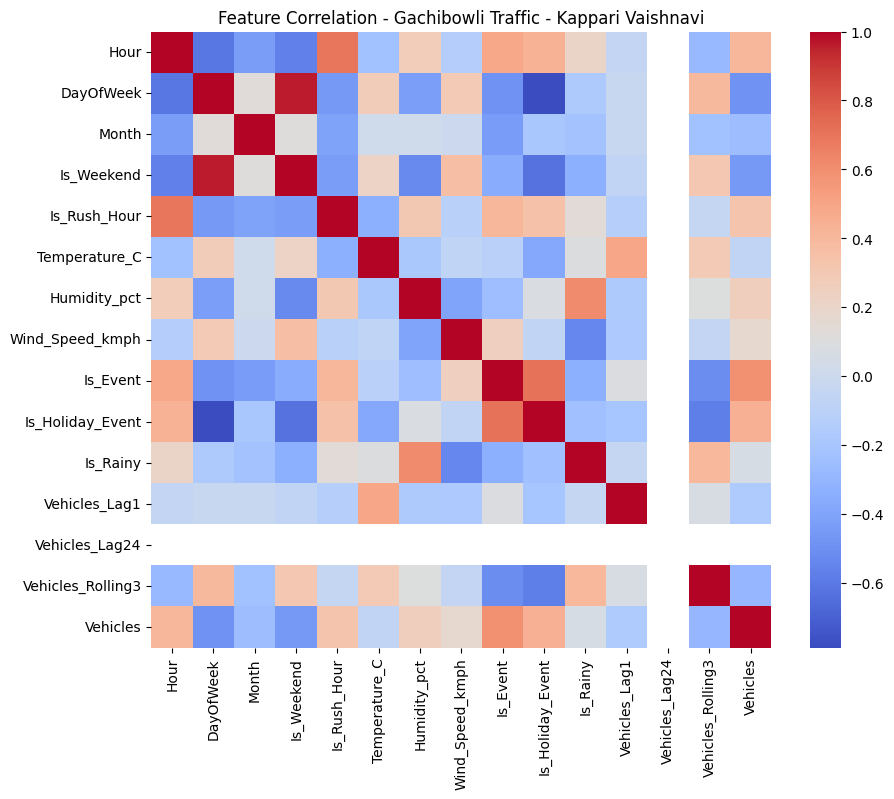


Top Influential Features for Model Training:
              Feature  Importance
0                Hour    0.228587
8            Is_Event    0.190093
11      Vehicles_Lag1    0.167558
5       Temperature_C    0.154671
6        Humidity_pct    0.086485
7     Wind_Speed_kmph    0.084744
2               Month    0.039055
1           DayOfWeek    0.011683
13  Vehicles_Rolling3    0.010461
4        Is_Rush_Hour    0.010028
10           Is_Rainy    0.009099
3          Is_Weekend    0.006942
9    Is_Holiday_Event    0.000596
12     Vehicles_Lag24    0.000000


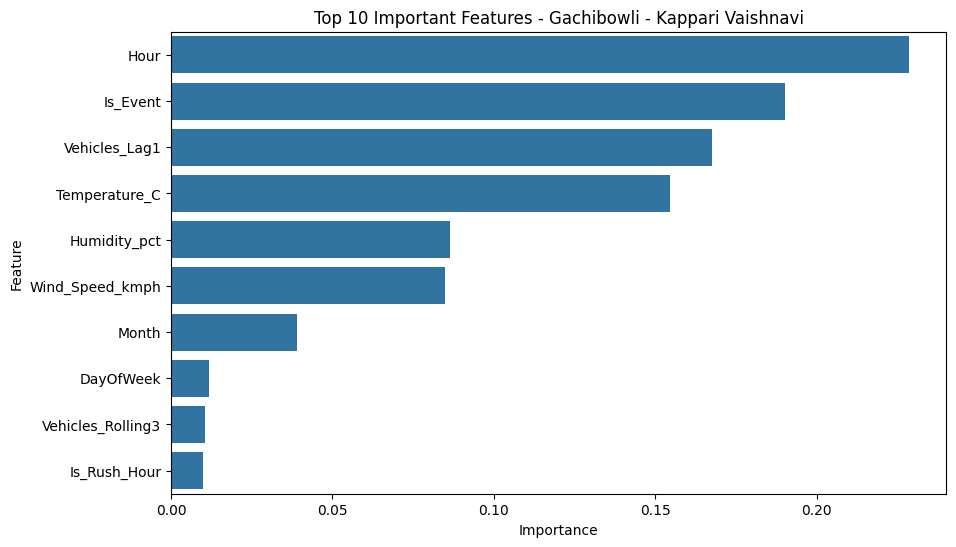


Selected Features for Model Training (efficiency): ['Hour', 'Is_Event', 'Vehicles_Lag1', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_kmph', 'Month']

Saved: Feature_Engineered_Gachibowli_Kappari_Vaishnavi.csv


In [6]:
# Task 2.2: Evaluate feature importance - Kappari Vaishnavi

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# Select numeric features for correlation
feature_cols = ['Hour','DayOfWeek','Month','Is_Weekend','Is_Rush_Hour',
                'Temperature_C','Humidity_pct','Wind_Speed_kmph',
                'Is_Event','Is_Holiday_Event','Is_Rainy',
                'Vehicles_Lag1','Vehicles_Lag24','Vehicles_Rolling3']

# Correlation analysis - statistical method
correlation = df[feature_cols + ['Vehicles']].corr()
print("Correlation with Vehicles (Traffic):")
print(correlation['Vehicles'].sort_values(ascending=False))

# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=False, cmap='coolwarm')
plt.title('Feature Correlation - Gachibowli Traffic - Kappari Vaishnavi')
plt.show()

# Tree-based feature importance - Random Forest
X = df[feature_cols].fillna(0)
y = df['Vehicles']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Influential Features for Model Training:")
print(importance)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Important Features - Gachibowli - Kappari Vaishnavi')
plt.show()

# Final selected features - Most influential
selected_features = importance[importance['Importance'] > 0.03]['Feature'].tolist()
print(f"\nSelected Features for Model Training (efficiency): {selected_features}")

# Save final engineered dataset
df.to_csv('Feature_Engineered_Gachibowli_Kappari_Vaishnavi.csv', index=False)
print("\nSaved: Feature_Engineered_Gachibowli_Kappari_Vaishnavi.csv")